In [1]:
# Manipulation et analyse des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# Modèles de régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Évaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Analyse statistique
from scipy.stats import pearsonr, spearmanr

In [2]:
# Chargement des données
df = pd.read_csv("data/raw/AirfoilSelfNoise.csv")

df.head()

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461


**1. Exploration et diagnostic initial des données**

In [3]:
# Vérification de la structure des données  
df.shape

(1503, 6)

In [4]:
# Vérification des types de données
df.dtypes

f               int64
alpha         float64
c             float64
U_infinity    float64
delta         float64
SSPL          float64
dtype: object

In [5]:
# Vérification des valeurs manquantes
df.isna().sum()

f             0
alpha         0
c             0
U_infinity    0
delta         0
SSPL          0
dtype: int64

In [6]:
# Vérification des doublons
df.duplicated().sum()

np.int64(0)

In [7]:
# Statistiques descriptives
df.describe()

,f,alpha,c,U_infinity,delta,SSPL
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


Letableau `describe()` montre que les données proviennent d’un **plan d’expérience contrôlé**, notamment pour `c` et `U_infinity`, qui prennent un nombre limité de valeurs répétées correspondant à différentes conditions expérimentales.

La variable `f` présente une **distribution asymétrique à droite**. Sa moyenne (2 886 Hz) est supérieure à sa médiane (1 600 Hz), tandis que sa valeur maximale atteint 20 000 Hz. La majorité des observations est donc concentrée dans les fréquences relativement basses, avec quelques valeurs très élevées.

La variable `alpha` varie de 0° à 22,2°, ce qui offre une diversité suffisante d’angles d’attaque pour étudier leur influence sur le niveau sonore. La variable `delta` est relativement dispersée, avec un écart-type (0,0132 m) supérieur à sa moyenne (0,0111 m).

Concernant la cible `SSPL`, le niveau sonore moyen est de 124,84 dB avec un écart-type de 6,90 dB, soit un coefficient de variation d’environ 5,5 %. La dispersion relative autour de la moyenne reste donc modérée. Cependant, l’écart entre le minimum (103,38 dB) et le maximum (140,99 dB) atteint 37,61 dB. Comme le décibel est une échelle logarithmique, cet écart représente une différence acoustique importante.

Enfin, aucun doublon n’a été détecté dans les données. À ce stade, les données semblent donc cohérentes et suffisamment variées pour poursuivre l’analyse exploratoire, notamment l’étude des distributions, des valeurs aberrantes et des relations entre les variables explicatives et `SSPL`.


In [8]:
# Vérification du nombre de valeurs uniques pour certaines colonnes
df[['c', 'U_infinity']].nunique()

c             6
U_infinity    4
dtype: int64

Même si `c` et `U_infinity` sont toutes les deux de type **`float64`**, `c` avec ses **6 valeurs distinctes** est une variable **quasi-catégorielle**, tandis que `U_infinity` avec ses **4 valeurs distinctes nettement séparées** est **catégorielle en pratique**.


**2. Analyse des distributions et détection des valeurs aberrantes**

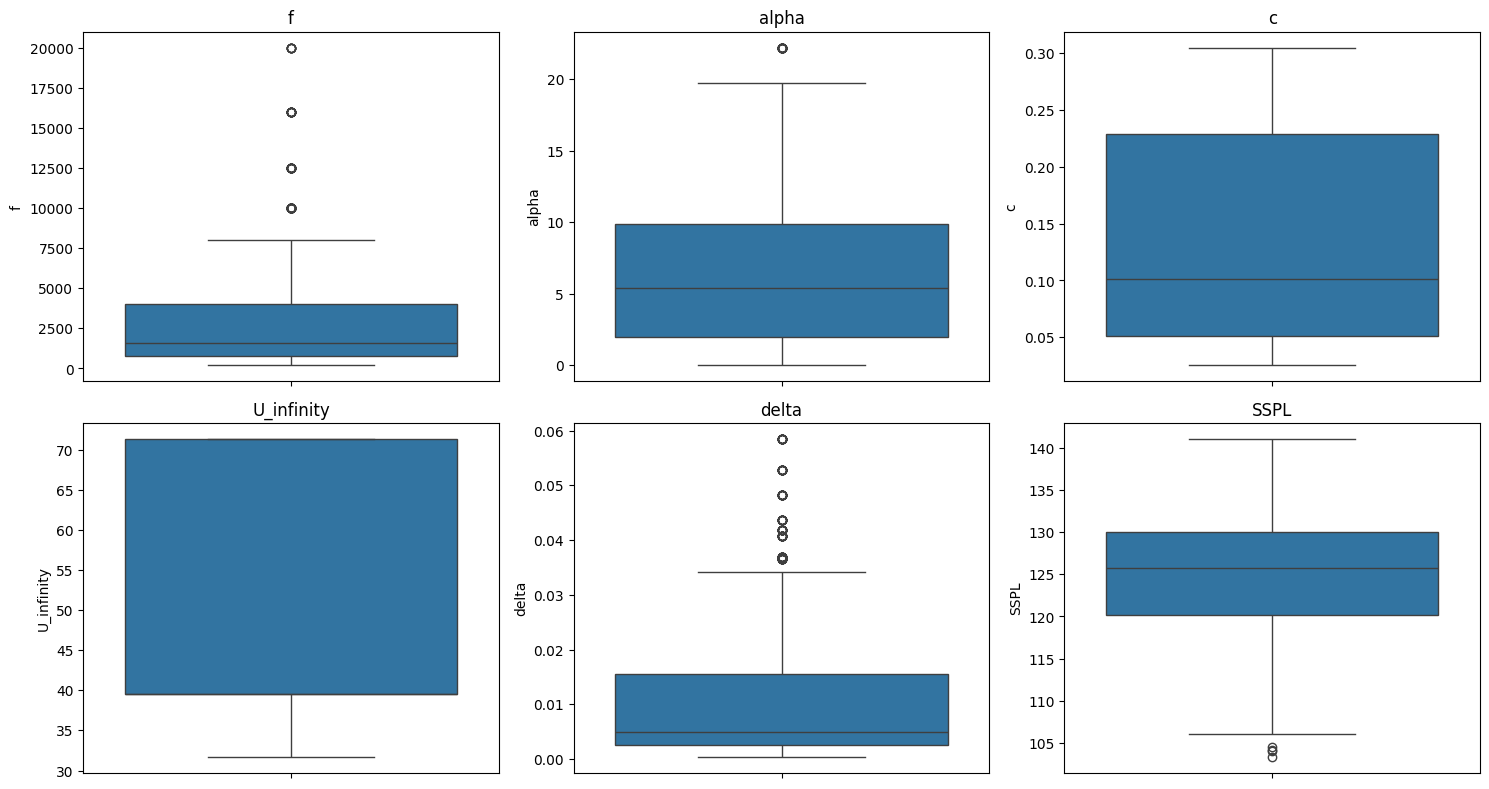

In [9]:
# Visualisation des distributions des variables avec des boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [10]:
# Vérifier si les valeurs extrêmes présentes dans la colonne 'f' sont des valeurs aberrantes ou non
df['f'].value_counts().sort_index()

f
200       35
250       42
315       56
400       69
500       78
630       88
800       97
1000      99
1250     100
1600     103
2000     105
2500     104
3150     103
4000     102
5000      95
6300      89
8000      52
10000     42
12500     25
16000     13
20000      6
Name: count, dtype: int64

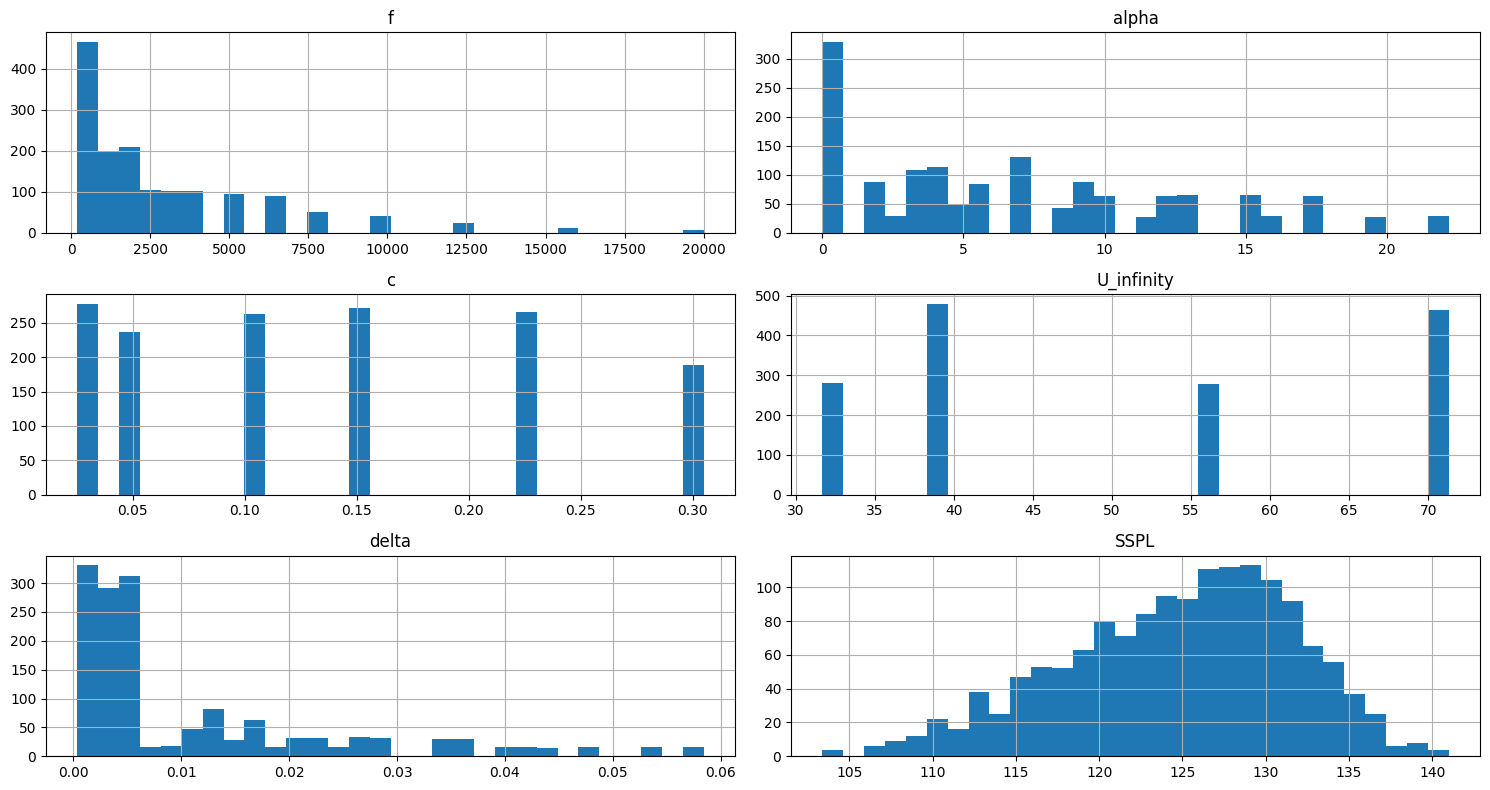

In [11]:
# Visualisation des relations entre les variables avec des scatter plots
df.hist(figsize=(15,8), bins=30)
plt.tight_layout()
plt.show()

In [12]:
# Vérifier si les valeurs extrêmes présentes dans la colonne 'delta' sont des valeurs aberrantes ou non
df['delta'].value_counts().sort_index()

delta
0.000401    10
0.000412    11
0.000428    11
0.000439    13
0.000740    13
            ..
0.041876    16
0.043726    14
0.048316    16
0.052849    16
0.058411    16
Name: count, Length: 105, dtype: int64

| Variable | Nature | Distribution | Outliers boxplot | Verdict |
|---|---|---|---|---|
| **f** | Quasi-catégorielle (21 valeurs distinctes, échelle normalisée en tiers d'octave, norme ISO) | Fortement asymétrique à droite (mean 2886 ≫ médiane 1600) | Points > 8000 Hz | **Pas des outliers** : valeurs répétées jusqu'à 6× à 20 000 Hz, mesures délibérées |
| **alpha** | Continue | Asymétrique à droite, pic massif à 0° (angle de référence) | 1 point isolé à 22,2° | Valeur plausible (maximum du protocole), à surveiller mais pas à supprimer |
| **c** | Catégorielle de fait (6 valeurs distinctes) | 6 pics nets, plan d'expérience | Aucun | RAS |
| **U_infinity** | Catégorielle de fait (4 valeurs distinctes) | 4 pics nets, plan d'expérience | Aucun | RAS |
| **delta** | Continue, **dérivée** (calculée à partir de `c`, `alpha`, `U_infinity`) | Fortement asymétrique à droite | Points > 0,035 | **Pas des outliers** : ~105 valeurs distinctes, chacune répétée 8 à 23 fois |
| **SSPL** (cible) | Continue | Proche d'une distribution normale, légère asymétrie à gauche | Quelques points bas ~104 dB | À surveiller en modélisation, mais physiquement plausible |

**3. Analyse exploratoire approfondie**

1. Quelles variables sont les plus associées à SSPL (force) ?
2. Ces relations sont-elles linéaires (Pearson) ou seulement monotones/non-linéaires (Spearman) ?
3. Comment c et U_infinity, en tant que conditions expérimentales discrètes, influencent-elles SSPL ?
4. Y a-t-il des interactions visibles entre variables physiques sur SSPL ? (exploration visuelle seulement à ce stade)

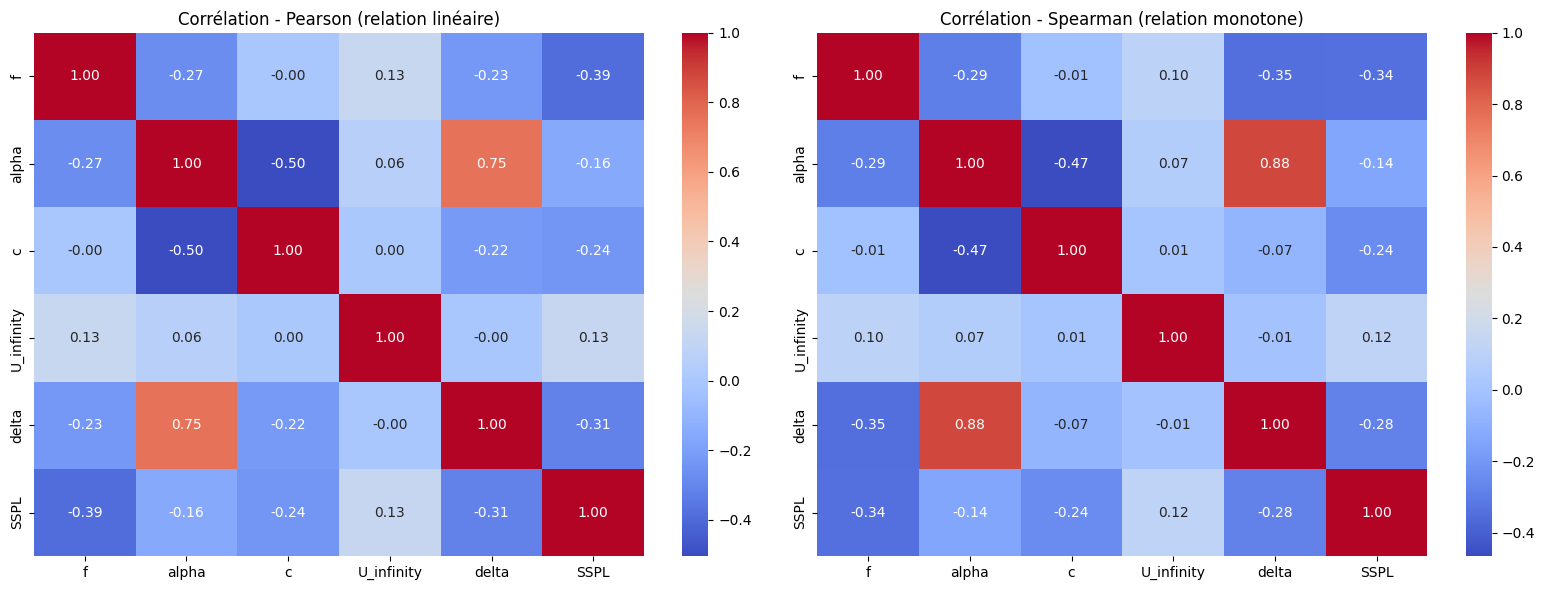

In [13]:
# Pour répondre à Q1 et Q2, commence par : Visualiser des relations entre les variables avec des heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df.corr(method='pearson'), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Corrélation - Pearson (relation linéaire)")

sns.heatmap(df.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Corrélation - Spearman (relation monotone)")

plt.tight_layout()
plt.show()

* 1. Quelles variables sont les plus associées à SSPL (force) ?

La variable la plus associée à SSPL est **f** (fréquence), avec une corrélation
modérée et négative (Pearson = -0.39, Spearman = -0.34). Viennent ensuite
**delta** (Pearson = -0.31, Spearman = -0.28) et **c** (Pearson = -0.24,
Spearman = -0.24). **alpha** (-0.16) et **U_infinity** (+0.13) montrent les
associations les plus faibles.

Aucune variable prise isolément n'explique fortement SSPL : les corrélations
restent toutes dans une plage modérée à faible (|r| < 0.4). Cela suggère que
le bruit résulte d'une combinaison de facteurs plutôt que d'une variable
dominante.

* 2. Ces relations sont-elles linéaires ou seulement monotones/non-linéaires ?

Les écarts entre Pearson et Spearman restent globalement faibles pour les
corrélations avec SSPL (écart maximal ≈ 0.05, sur f), ce qui suggère des
relations plutôt linéaires quand elles existent.

Cependant, l'exploration visuelle (scatterplot f vs SSPL) révèle une relation
**non-monotone** que ni Pearson ni Spearman ne peuvent capturer : SSPL est
plus élevé pour les fréquences intermédiaires (~1000-10000 Hz) et diminue aux
extrémités. Les coefficients de corrélation globaux sous-estiment donc la
complexité réelle de cette relation.

Le **boxplot par groupe** permet de voir si le niveau sonore médian varie selon la longueur de corde (`c`) ou la vitesse du flux (`U_infinity`). Ce sont des conditions expérimentales discrètes, avec respectivement 6 et 4 valeurs distinctes, donc un boxplot par groupe est plus pertinent qu’un scatterplot ici.


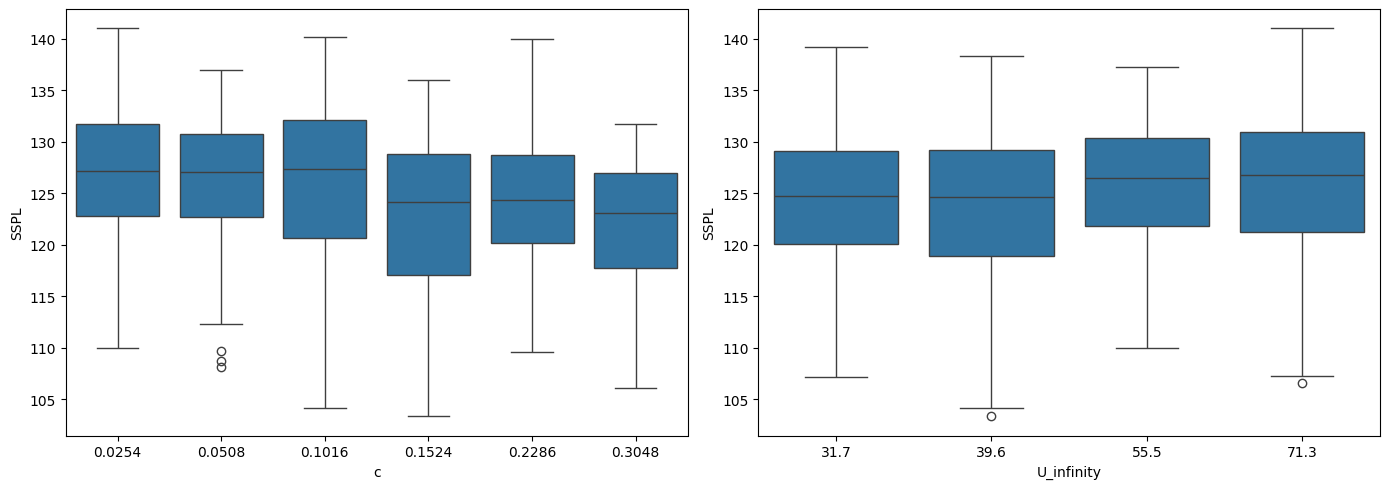

In [14]:
# Pour répondre à Q3 et Q4, commence par : 
# 1.Visualiser Boxplots de SSPL par groupe en fonction de c et U_infinity
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='c', y='SSPL', data=df, ax=axes[0])
sns.boxplot(x='U_infinity', y='SSPL', data=df, ax=axes[1])
plt.tight_layout()
plt.show()

**3. Comment c et U_infinity influencent-elles SSPL ?**

* **c** : effet significatif mais faible (Kruskal-Wallis, H = 102,92, p < 0,001, ε² = 0,065). Contrairement à l'impression initiale d'une diminution progressive, les médianes révèlent un **effet de palier** : SSPL reste stable autour de 127 dB pour c ≤ 0,1016 m, puis chute à 123-124 dB pour c ≥ 0,1524 m. Le post-hoc de Dunn (Holm) confirme que cette rupture est significative pour 10 des 15 paires de groupes (essentiellement entre les deux blocs), mais pas à l'intérieur de chaque bloc.

* **U_infinity** : effet significatif mais encore plus faible que c (Kruskal-Wallis, H = 27,24, p < 0,001, ε² = 0,016, environ 4 fois plus faible que celui de c). Les médianes augmentent légèrement avec la vitesse, avec un chevauchement important entre groupes, cohérent avec la corrélation Pearson mesurée (+0,13).

Ces deux variables, bien que discrètes (plan d'expérience), ont un effet statistiquement démontré sur SSPL, mais d'ampleur faible prises individuellement. **c a un impact plus marqué que U_infinity.**

**4. Y a-t-il des interactions visibles entre variables physiques sur SSPL ?**

À ce stade, seule une exploration visuelle a été menée, sans test formel d'interaction. La forme non monotone observée sur f vs SSPL suggère que d'autres variables, notamment alpha et U_infinity, pourraient moduler cette relation. Par exemple, l'effet de la fréquence sur le bruit pourrait différer selon la vitesse du flux ou l'angle d'attaque. Cette hypothèse devra être étudiée plus formellement lors du feature engineering et de la modélisation, notamment avec des modèles non linéaires et des termes d'interaction.


In [15]:
# Vérification des types de données
df.dtypes

f               int64
alpha         float64
c             float64
U_infinity    float64
delta         float64
SSPL          float64
dtype: object

Le **scatterplot en échelle logarithmique** permet de vérifier visuellement si la relation entre `f` et `SSPL` devient plus linéaire après avoir corrigé l’asymétrie de `f` observée dans les histogrammes.

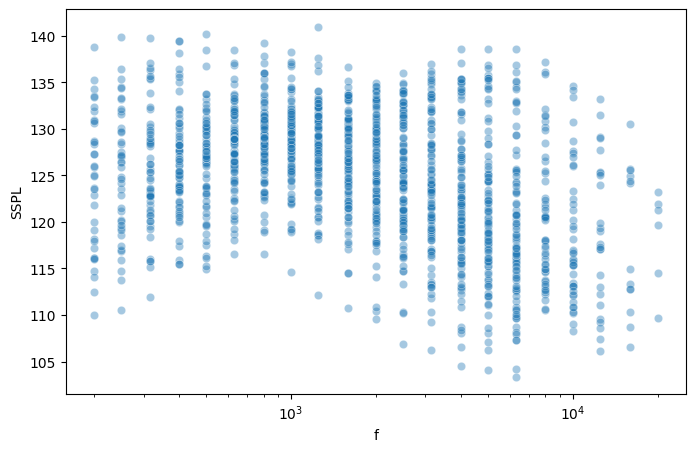

In [16]:
# 2. Scatterplot f vs SSPL
plt.figure(figsize=(8,5))
sns.scatterplot(x='f', y='SSPL', data=df, alpha=0.4)
plt.xscale('log')
plt.show()

Le nuage est dispersé et ne suit pas une tendance linéaire. On observe une 
forme non-monotone : SSPL semble plus élevé pour les fréquences intermédiaires 
(environ 1000 à 10000 Hz), puis diminue légèrement au-delà. Cette forme "en 
cloche aplatie" explique pourquoi les corrélations globales (Pearson = -0.39, 
Spearman = -0.34) ne capturent que partiellement la relation réelle entre f 
et SSPL, celle-ci n'étant ni linéaire ni purement monotone.

**4. Tests statistiques**

In [17]:
# Vérification des conditions nécessaires pour comparer statistiquement SSPL entre les groupes de c
from scipy import stats

# Test de normalité de SSPL dans chaque groupe de c
for val in sorted(df['c'].unique()):
    groupe = df[df['c'] == val]['SSPL']
    stat, p = stats.shapiro(groupe)
    print(f"c={val} : p-value Shapiro = {p:.4f}")

# Test d'homogénéité des variances entre les groupes
groupes_c = [df[df['c'] == val]['SSPL'] for val in sorted(df['c'].unique())]
stat_levene, p_levene = stats.levene(*groupes_c)
print(f"\nLevene : stat = {stat_levene:.4f}, p-value = {p_levene:.4f}")

c=0.0254 : p-value Shapiro = 0.0049
c=0.0508 : p-value Shapiro = 0.0001
c=0.1016 : p-value Shapiro = 0.0000
c=0.1524 : p-value Shapiro = 0.0000
c=0.2286 : p-value Shapiro = 0.0174
c=0.3048 : p-value Shapiro = 0.0000

Levene : stat = 7.1919, p-value = 0.0000


Dans les 6 groupes de `c`, la normalité de `SSPL` est rejetée. Les distributions de `SSPL` ne suivent donc pas une loi normale dans ces groupes.

**Question 1 : Le niveau de bruit SSPL diffère-t-il selon la longueur de corde c ?**

- **H0 :** les médianes de SSPL sont identiques entre les 6 groupes de c.
- **H1 :** au moins un groupe présente une médiane différente.
- **α = 5 %**
- **Test choisi :** Kruskal-Wallis, justifié par le rejet de la normalité et de l'homogénéité des variances.

In [18]:
# Test de Kruskal-Wallis : influence de c sur SSPL
groupes_c = [df[df['c'] == val]['SSPL'] for val in sorted(df['c'].unique())]
stat, p = stats.kruskal(*groupes_c)
print(f"Kruskal-Wallis : stat = {stat:.4f}, p-value = {p:.4f}")

Kruskal-Wallis : stat = 102.9195, p-value = 0.0000


- Test utilisé : Kruskal-Wallis, car les conditions de normalité (Shapiro, p < 0,05 pour les 6 groupes) et d'homogénéité des variances (Levene, p < 0,001) ne sont pas respectées.

- Statistique de Kruskal-Wallis = 102,92

- p-value < 0,001

- Taille d'effet (epsilon-squared) = 0,065 → effet faible

**Décision** : p-value < 0,05, donc nous rejetons H0.

**Conclusion** : Le niveau sonore SSPL diffère significativement selon la longueur de corde c (p < 0,001). La longueur de corde a une influence statistiquement significative sur le niveau sonore mesuré. Cependant, l'ampleur de cet effet reste faible (ε² = 0,065) : c n'explique qu'une faible partie de la variabilité de SSPL. Avec 1503 observations, même un effet modeste peut devenir statistiquement détectable. La significativité statistique ne doit donc pas être confondue avec une importance pratique forte.

⚠️ Le test de Kruskal-Wallis indique qu'il existe une différence entre au moins deux groupes, mais ne précise pas lesquels. Un test post-hoc de Dunn avec correction de Holm est nécessaire pour identifier les paires de groupes qui diffèrent significativement.

In [19]:
# Calcul de la taille d'effet du test de Kruskal-Wallis pour mesurer l'importance de l'effet de c sur SSPL
H = 102.9195
k = df['c'].nunique()
n = len(df)

epsilon_sq = (H - k + 1) / (n - k)
print(f"Epsilon-squared = {epsilon_sq:.4f}")

Epsilon-squared = 0.0654


L'epsilon-squared = 0,0654 (6,54 %). Selon les seuils usuels d'interprétation
(Cohen), cette valeur correspond à un effet faible (0,01 ≤ ε² < 0,08).

Conclusion : la longueur de corde c a un effet statistiquement significatif
sur SSPL (p < 0,001), mais cet effet reste faible en ampleur. Elle
n'explique donc qu'une petite partie des variations du niveau sonore, ce qui
confirme que d'autres variables jouent un rôle plus important dans
l'explication du bruit mesuré.

**Question 2** : Le niveau sonore SSPL diffère-t-il selon la vitesse du flux U_infinity ?

In [20]:
# Vérification de la normalité de SSPL dans chaque groupe de U_infinity
for val in sorted(df['U_infinity'].unique()):
    groupe = df[df['U_infinity'] == val]['SSPL']
    stat, p = stats.shapiro(groupe)
    print(f"U_infinity={val} : p-value Shapiro = {p:.4f}")

U_infinity=31.7 : p-value Shapiro = 0.0028
U_infinity=39.6 : p-value Shapiro = 0.0000
U_infinity=55.5 : p-value Shapiro = 0.0001
U_infinity=71.3 : p-value Shapiro = 0.0000


Dans les 4 groupes de U_infinity, la normalité de SSPL est rejetée. Les distributions de SSPL ne suivent donc pas une loi normale dans ces groupes.

In [21]:
# Vérification de l'homogénéité des variances entre les groupes de U_infinity (Levene)
groupes_u = [df[df['U_infinity'] == val]['SSPL']
             for val in sorted(df['U_infinity'].unique())]

stat_levene, p_levene = stats.levene(*groupes_u)

print(f"Levene : stat = {stat_levene:.4f}, p-value = {p_levene:.4f}")

Levene : stat = 2.4768, p-value = 0.0598


**Test de Kruskal-Wallis : influence de U_infinity sur SSPL**

**Question :** Le niveau de bruit SSPL diffère-t-il selon la vitesse du flux U_infinity ?

**H0 :** les distributions de SSPL sont identiques entre les 4 groupes de U_infinity.

**H1 :** au moins un groupe présente une distribution de SSPL différente.

**α = 5 %**

**Test choisi :** Kruskal-Wallis, car la normalité n'est pas respectée malgré l'homogénéité des variances.

In [22]:
# Test de Kruskal-Wallis : influence de U_infinity sur SSPL
groupes_u = [df[df['U_infinity'] == val]['SSPL']
             for val in sorted(df['U_infinity'].unique())]

stat, p = stats.kruskal(*groupes_u)

print(f"Kruskal-Wallis : stat = {stat:.4f}, p-value = {p:.4f}")

Kruskal-Wallis : stat = 27.2436, p-value = 0.0000


In [23]:
# Calcul de la taille d'effet du test de Kruskal-Wallis pour mesurer l'importance de l'effet de U_infinity sur SSPL
H = 27.2436
k = df['U_infinity'].nunique()
n = len(df)

epsilon_sq = (H - k + 1) / (n - k)
print(f"Epsilon-squared = {epsilon_sq:.4f}")

Epsilon-squared = 0.0162


- Test utilisé : Kruskal-Wallis, car la condition de normalité (Shapiro, p < 0,05 pour les 4 groupes) n'est pas respectée, malgré l'homogénéité des variances (Levene, p = 0,0598).

- Statistique de Kruskal-Wallis = 27,24

- p-value < 0,001

- Taille d'effet (epsilon-squared) = 0,0162 → effet faible

**Décision** : p-value < 0,05, donc nous rejetons H0.

**Conclusion** : Le niveau sonore SSPL diffère significativement selon la vitesse du flux U_infinity (p < 0,001). La vitesse du flux a donc une influence statistiquement significative sur le niveau sonore mesuré. Cependant, l'ampleur de cet effet reste faible (ε² = 0,0162) : U_infinity n'explique qu'une faible partie de la variabilité de SSPL. La significativité statistique ne doit donc pas être confondue avec une importance pratique forte.

⚠️ Le test de Kruskal-Wallis indique qu'il existe une différence entre au moins deux groupes, mais ne précise pas lesquels. Un test post-hoc de Dunn avec correction de Holm est nécessaire pour identifier les paires de groupes qui diffèrent significativement.

**Synthèse : Effet des conditions expérimentales sur SSPL (Question 3)**

| Variable | Test | Statistique | p-value | ε² | Ampleur effet | Décision |
|---|---|---|---|---|---|---|
| c | Kruskal-Wallis | H = 102,92 | < 0,001 | 0,065 | Faible | Rejet H0 |
| U_infinity | Kruskal-Wallis | H = 27,24 | < 0,001 | 0,016 | Faible | Rejet H0 |

**Interprétation comparative** : les deux variables expérimentales (c et
U_infinity) ont un effet statistiquement significatif sur SSPL, mais c a un
effet plus marqué que U_infinity (ε² = 0,065 contre 0,016, environ 4 fois
plus élevé). Dans les deux cas, l'effet individuel reste faible, ce qui
confirme que SSPL résulte probablement d'une combinaison de facteurs plutôt
que d'une seule variable dominante.

In [24]:
# Test post-hoc de Dunn pour identifier les groupes de c dont les niveaux de SSPL diffèrent significativement
import scikit_posthocs as sp

dunn_results = sp.posthoc_dunn(df, val_col='SSPL', group_col='c', p_adjust='holm')
print(dunn_results)

              0.0254        0.0508        0.1016        0.1524    0.2286  \
0.0254  1.000000e+00  1.000000e+00  9.882427e-01  7.908876e-09  0.000002   
0.0508  1.000000e+00  1.000000e+00  1.000000e+00  3.356573e-06  0.000244   
0.1016  9.882427e-01  1.000000e+00  1.000000e+00  7.025432e-06  0.000477   
0.1524  7.908876e-09  3.356573e-06  7.025432e-06  1.000000e+00  1.000000   
0.2286  2.206734e-06  2.436174e-04  4.768991e-04  1.000000e+00  1.000000   
0.3048  1.064671e-13  1.767100e-10  3.754712e-10  1.432189e-01  0.014526   

              0.3048  
0.0254  1.064671e-13  
0.0508  1.767100e-10  
0.1016  3.754712e-10  
0.1524  1.432189e-01  
0.2286  1.452613e-02  
0.3048  1.000000e+00  


10 des 15 paires possibles (66,7 %) présentent une différence significative (p < 0,05).

Les comparaisons significatives opposent principalement les faibles valeurs de c (0,0254, 0,0508, 0,1016), qui ne diffèrent pas significativement entre elles, aux valeurs de c plus élevées (0,1524, 0,2286, 0,3048). Cela suggère une rupture du niveau de SSPL autour de c ≈ 0,13, plutôt qu'une diminution strictement progressive et continue.

⚠️ Le test de Dunn indique quelles paires diffèrent, mais pas le sens de la différence. Le sens, notamment la diminution de SSPL avec c, doit être confirmé par les médianes observées lors de l'EDA.


In [25]:
# Calcul des médianes de SSPL pour chaque groupe de c afin de comparer les niveaux de bruit
df.groupby('c')['SSPL'].median()

c
0.0254    127.162
0.0508    127.076
0.1016    127.318
0.1524    124.121
0.2286    124.321
0.3048    123.065
Name: SSPL, dtype: float64

Les médianes confirment un effet de **palier** plutôt qu'une tendance linéaire
continue : SSPL reste stable autour de 127 dB pour c ≤ 0,1016 m, puis chute
à environ 123-124 dB pour c ≥ 0,1524 m. Cette rupture, cohérente avec les
10 paires significatives identifiées par le test de Dunn, suggère un effet
de seuil physique plutôt qu'une relation strictement proportionnelle entre
la longueur de corde et le niveau sonore.

**Test de significativité de la corrélation entre f et SSPL**

**Question** : Existe-t-il une relation significative entre f et SSPL ?

- H0 : ρ = 0 (il n'existe pas de corrélation entre f et SSPL dans la population)
- H1 : ρ ≠ 0 (il existe une corrélation entre f et SSPL dans la population)
- α = 5 %

In [26]:
# Test de corrélation entre les variables f, alpha, delta et SSPL
variables = ['f', 'alpha', 'delta']

for var in variables:
    r_pearson, p_pearson = stats.pearsonr(df[var], df['SSPL'])
    r_spearman, p_spearman = stats.spearmanr(df[var], df['SSPL'])
    print(f"{var} :")
    print(f"  Pearson  r = {r_pearson:.4f}, p-value = {p_pearson:.4g}")
    print(f"  Spearman r = {r_spearman:.4f}, p-value = {p_spearman:.4g}")
    print()

f :
  Pearson  r = -0.3907, p-value = 5.362e-56
  Spearman r = -0.3408, p-value = 3.487e-42

alpha :
  Pearson  r = -0.1561, p-value = 1.17e-09
  Spearman r = -0.1408, p-value = 4.25e-08

delta :
  Pearson  r = -0.3127, p-value = 1.925e-35
  Spearman r = -0.2798, p-value = 1.921e-28



**1. f et SSPL**

- Statistique (Pearson) : r = -0,3907
- p-value : 5,362 × 10⁻⁵⁶
- Décision : rejet de H0 (p < 0,05)
- Interprétation : il existe une relation négative et modérée entre la fréquence `f` et `SSPL`. Lorsque `f` augmente, `SSPL` a tendance à diminuer. Cette relation est statistiquement significative, mais son intensité reste modérée. Comme la relation observée est non monotone, Pearson et Spearman peuvent sous-estimer le lien réel entre les deux variables.

**2. alpha et SSPL**

- Statistique (Pearson) : r = -0,1561
- p-value : 1,17 × 10⁻⁹
- Décision : rejet de H0 (p < 0,05)
- Interprétation : il existe une relation négative et faible entre l'angle d'attaque `alpha` et `SSPL`. Lorsque `alpha` augmente, `SSPL` a légèrement tendance à diminuer. Cette relation est statistiquement significative, mais son intensité reste faible. `alpha` est la variable la moins corrélée à `SSPL` parmi les trois variables étudiées, ce qui est cohérent avec la matrice de corrélation observée lors de l'EDA.

**3. delta et SSPL**

- Statistique (Pearson) : r = -0,3127
- p-value : 1,925 × 10⁻³⁵
- Décision : rejet de H0 (p < 0,05)
- Interprétation : il existe une relation négative et modérée entre l'épaisseur de déplacement `delta` et `SSPL`. Lorsque `delta` augmente, `SSPL` a tendance à diminuer. Cette relation est statistiquement significative et plus marquée que celle observée pour `alpha`, mais moins forte que celle observée pour `f`.

⚠️ Rappel méthodologique : `delta` est une variable dérivée de `c`, `alpha` et `U_infinity` (cf. Data Understanding). Sa corrélation avec `SSPL` ne doit donc pas être interprétée comme un effet physique indépendant. Elle reflète en partie la combinaison des variables dont elle dépend. Ce point devra être surveillé lors de la modélisation, notamment avec le VIF et la sélection des variables, afin d'éviter une redondance d'information.

**5. Feature Engineering**

In [27]:
# Calcul du nombre de Reynolds (Re) pour caractériser le régime d'écoulement
# autour du profil. Re combine c et U_infinity avec une base physique
# documentée (Brooks, Pope & Marcolini, 1989) — préféré à un seuil arbitraire
# sur c seul, qui n'a pas de justification physique indépendante des données.
#
# Note méthodologique : une première piste envisagée consistait à créer une
# variable binaire c_high (seuil à 0,13 m) pour capturer l'effet de palier
# observé sur c lors des tests d'hypothèses (Kruskal-Wallis + Dunn). Ce
# seuil a été écarté : il avait été déterminé en observant directement la
# relation entre c et SSPL, ce qui constitue une forme de data leakage
# (la cible influence la construction de la feature). Re est retenue à la
# place, car elle repose sur une justification physique indépendante des
# données observées.
nu = 1.5e-5  # viscosité cinématique de l'air à ~15°C, en m²/s
df['Re'] = (df['U_infinity'] * df['c']) / nu

In [28]:
# Test de corrélation entre Re et SSPL
r_pearson, p_pearson = stats.pearsonr(df['Re'], df['SSPL'])
r_spearman, p_spearman = stats.spearmanr(df['Re'], df['SSPL'])
print(f"Re : Pearson r = {r_pearson:.4f} (p={p_pearson:.4g}), Spearman r = {r_spearman:.4f} (p={p_spearman:.4g})")

Re : Pearson r = -0.1613 (p=3.165e-10), Spearman r = -0.1829 (p=8.887e-13)


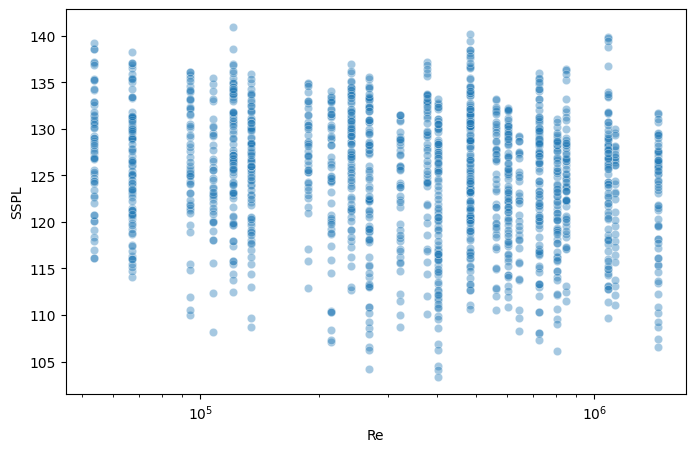

In [29]:
# Visualisation de la relation entre Re et SSPL
plt.figure(figsize=(8,5))
sns.scatterplot(x='Re', y='SSPL', data=df, alpha=0.4)
plt.xscale('log')
plt.show()

In [30]:
# Vérifier l'existence de valeurs incompatibles avec le logarithme
(df['f'] <= 0).sum()

np.int64(0)

In [31]:
# Transformation logarithmique de la fréquence pour réduire son asymétrie
df['log_f'] = np.log10(df['f'])

In [32]:
# Comparer les statistiques de f avant et après transformation
df[['f', 'log_f']].describe()

,f,log_f
count,1503.000000,1503.000000
mean,2886.380572,3.224877
std,3152.573137,0.471137
min,200.000000,2.301030
25%,800.000000,2.903090
50%,1600.000000,3.204120
75%,4000.000000,3.602060
max,20000.000000,4.301030


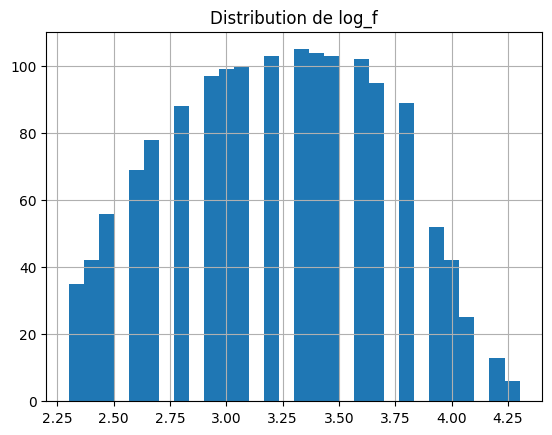

In [33]:
# Visualiser la distribution de log_f pour vérifier si elle est plus symétrique que celle de f
df['log_f'].hist(bins=30)
plt.title("Distribution de log_f")
plt.show()

In [34]:
# Calcul du VIF pour détecter la multicolinéarité entre les variables explicatives
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Sélection des variables utilisées pour le calcul du VIF
X = df[['f', 'log_f', 'alpha', 'c', 'U_infinity', 'Re', 'delta']]

# Création du tableau des résultats
vif_data = pd.DataFrame()

# Calcul du VIF pour chaque variable
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Affichage des résultats
print(vif_data)

     variable        VIF
0           f   3.730509
1       log_f  40.088625
2       alpha   7.731628
3           c  31.447837
4  U_infinity  31.003316
5          Re  32.056583
6       delta   4.356208


1. Retenir `log_f` et écarter `f` : `log_f` réduit l'asymétrie de la fréquence et évite de conserver deux représentations redondantes de la même variable.
2. Retenir `c` et `U_infinity`, écarter `Re` : `Re` est une combinaison mathématique de `c` et `U_infinity`, présente une forte colinéarité avec elles et n'a pas montré de relation plus intéressante avec `SSPL`

In [35]:
# Calcul du VIF final pour vérifier la multicolinéarité entre les variables retenues
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_final = df[['log_f', 'alpha', 'c', 'U_infinity', 'delta']]
X_final_const = add_constant(X_final)  # ajout de l'intercept, obligatoire

vif_final = pd.DataFrame()
vif_final['variable'] = X_final_const.columns
vif_final['VIF'] = [variance_inflation_factor(X_final_const.values, i) for i in range(X_final_const.shape[1])]

# On retire la ligne 'const' du résultat final, elle ne s'interprète pas comme les autres
vif_final = vif_final[vif_final['variable'] != 'const']
print(vif_final)

     variable       VIF
1       log_f  1.152202
2       alpha  3.433027
3           c  1.509550
4  U_infinity  1.034149
5       delta  2.530619


**6. Modélisation**

In [36]:
# Séparation des variables explicatives et de la variable cible
from sklearn.model_selection import train_test_split

X = df[['log_f', 'alpha', 'c', 'U_infinity', 'delta']]
y = df['SSPL']

# Division des données en 80 % pour l'entraînement et 20 % pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# Vérification des dimensions des jeux d'entraînement et de test
X_train.shape, X_test.shape

((1202, 5), (301, 5))

In [38]:
# Import des métriques utilisées pour évaluer les modèles de régression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modèle de référence (baseline) : régression linéaire, sans régularisation.
# Sert de point de comparaison pour juger si les modèles plus complexes
# (Ridge, Lasso, Random Forest, Gradient Boosting) apportent un réel gain.
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prédictions sur le jeu de test, jamais vu par le modèle pendant l'entraînement
y_pred_lr = lr.predict(X_test)

# MAE : erreur moyenne absolue, dans l'unité d'origine (dB) — facile à interpréter
mae = mean_absolute_error(y_test, y_pred_lr)

# RMSE : pénalise davantage les grosses erreurs que la MAE (à cause du carré)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# R² : proportion de la variance de SSPL expliquée par le modèle (entre 0 et 1)
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R²   = {r2:.3f}")

MAE  = 3.845
RMSE = 4.874
R²   = 0.526


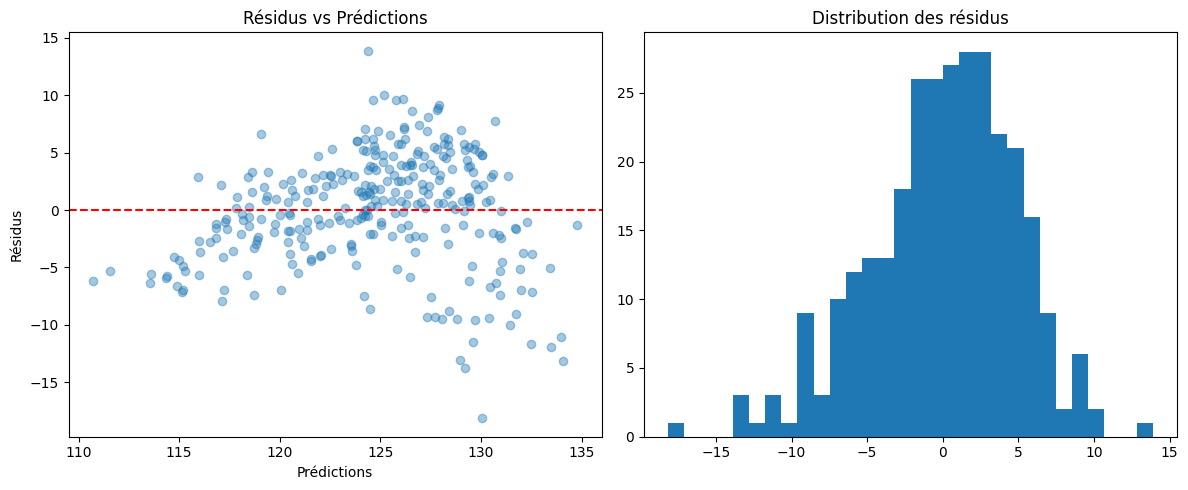

In [39]:
# Calcul des résidus entre les valeurs réelles et les prédictions
residus = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Résidus vs prédictions : cherche un pattern (courbe, entonnoir) = signe de non-linéarité non capturée
axes[0].scatter(y_pred_lr, residus, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Prédictions")
axes[0].set_ylabel("Résidus")
axes[0].set_title("Résidus vs Prédictions")

# Distribution des résidus : devrait ressembler à une loi normale centrée sur 0
axes[1].hist(residus, bins=30)
axes[1].set_title("Distribution des résidus")

plt.tight_layout()
plt.show()

Les résidus sont globalement centrés autour de 0, mais présentent une
dispersion croissante pour les valeurs prédites élevées (hétéroscédasticité),
ainsi que quelques observations avec des résidus importants (>10 dB en
valeur absolue). Aucune courbure nette n'est visible, ce qui ne permet pas
de confirmer directement une non-linéarité globale à partir de ce seul
diagnostic. Ces éléments suggèrent des pistes d'amélioration (modèles
non-linéaires, ou régularisation pour limiter l'effet des observations
atypiques), à évaluer par comparaison de performance plutôt que par
diagnostic visuel seul.

In [40]:
# STANDARDISATION DES DONNÉES

# Création du standardiseur
scaler = StandardScaler()

# Le scaler apprend la moyenne et l'écart-type uniquement sur X_train, puis standardise X_train
X_train_scaled = scaler.fit_transform(X_train)

# On applique les mêmes paramètres appris sur X_train à X_test sans recalculer la moyenne et l'écart-type
X_test_scaled = scaler.transform(X_test)


# =========================
# MODÈLE RIDGE
# =========================

# Création du modèle Ridge
# alpha=1.0 contrôle l'intensité de la pénalisation
ridge = Ridge(alpha=1.0)

# Entraînement du modèle sur les données standardisées
ridge.fit(X_train_scaled, y_train)

# Prédiction sur les données de test standardisées
y_pred_ridge = ridge.predict(X_test_scaled)

# Calcul de l'erreur absolue moyenne
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# Calcul de la racine de l'erreur quadratique moyenne
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# Calcul du coefficient de détermination R²
r2_ridge = r2_score(y_test, y_pred_ridge)


# =========================
# MODÈLE LASSO
# =========================

# Création du modèle Lasso
# alpha=1.0 contrôle l'intensité de la pénalisation
lasso = Lasso(alpha=1.0)

# Entraînement du modèle sur les données standardisées
lasso.fit(X_train_scaled, y_train)

# Prédiction sur les données de test standardisées
y_pred_lasso = lasso.predict(X_test_scaled)

# Calcul de l'erreur absolue moyenne
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

# Calcul de la racine de l'erreur quadratique moyenne
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# Calcul du coefficient de détermination R²
r2_lasso = r2_score(y_test, y_pred_lasso)


# =========================
# AFFICHAGE DES RÉSULTATS
# =========================

# Affichage des performances du modèle Ridge
print("Ridge :", f"MAE={mae_ridge:.3f}", f"RMSE={rmse_ridge:.3f}", f"R²={r2_ridge:.3f}")

# Affichage des performances du modèle Lasso
print("Lasso :", f"MAE={mae_lasso:.3f}", f"RMSE={rmse_lasso:.3f}", f"R²={r2_lasso:.3f}")

Ridge : MAE=3.846 RMSE=4.875 R²=0.526
Lasso : MAE=4.765 RMSE=5.810 R²=0.326


In [41]:
# Comparaison des coefficients des modèles Ridge et Lasso

coef_lasso = pd.DataFrame({
    'variable': X_train.columns,
    'coefficient': lasso.coef_
})

print(coef_lasso)

     variable  coefficient
0       log_f    -2.001033
1       alpha    -0.000000
2           c    -0.972827
3  U_infinity     0.077326
4       delta    -1.693465


In [42]:
# Création d'un tableau pour comparer les coefficients des deux modèles
comparaison = pd.DataFrame({
    'variable': X_train.columns,
    'coef_ridge': ridge.coef_,
    'coef_lasso': lasso.coef_
})
print(comparaison)

     variable  coef_ridge  coef_lasso
0       log_f   -3.851829   -2.001033
1       alpha   -2.211971   -0.000000
2           c   -3.108852   -0.972827
3  U_infinity    1.422923    0.077326
4       delta   -1.997754   -1.693465


Lasso ne fait pas que supprimer alpha, il réduit également fortement plusieurs autres coefficients. Cela renforce l'hypothèse que alpha=1.0 est trop élevé et provoque une sur-régularisation. Il faut maintenant regarder le résultat de LassoCV pour vérifier si un alpha plus faible améliore les performances.

In [43]:
# Recherche du meilleur alpha pour Lasso
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 2, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Meilleur alpha (Lasso) : {lasso_cv.alpha_:.4f}")

Meilleur alpha (Lasso) : 0.0010


In [44]:
# Création du modèle Lasso avec l'alpha optimal trouvé par validation croisée
lasso_optimal = Lasso(alpha=lasso_cv.alpha_)

# Entraînement du modèle Lasso optimisé sur les données d'entraînement standardisées
lasso_optimal.fit(X_train_scaled, y_train)

# Prédiction sur les données de test standardisées
y_pred_lasso_opt = lasso_optimal.predict(X_test_scaled)

# Calcul du MAE : erreur absolue moyenne
mae_lasso_opt = mean_absolute_error(y_test, y_pred_lasso_opt)

# Calcul du RMSE : pénalise davantage les grandes erreurs
rmse_lasso_opt = np.sqrt(mean_squared_error(y_test, y_pred_lasso_opt))

# Calcul du R² : mesure la proportion de variance expliquée par le modèle
r2_lasso_opt = r2_score(y_test, y_pred_lasso_opt)

# Affichage des performances du Lasso avec l'alpha optimal
print(f"Lasso (alpha optimal) : MAE={mae_lasso_opt:.3f}, RMSE={rmse_lasso_opt:.3f}, R²={r2_lasso_opt:.3f}")

Lasso (alpha optimal) : MAE=3.846, RMSE=4.875, R²=0.526


**Synthèse : modèles linéaires (baseline + régularisés)**

Les trois modèles linéaires, **Linear Regression, Ridge et Lasso optimisé**, convergent vers des performances très proches : **R² ≈ 0,526** et **MAE ≈ 3,85 dB**. La régularisation n'apporte donc pas de gain significatif ici, ce qui est cohérent avec l'absence de multicolinéarité problématique détectée par le VIF, toutes les variables ayant un VIF inférieur à 5.

Point méthodologique important : avec `alpha=1.0`, le Lasso obtenait un **R² de 0,326**, en raison d'une pénalisation trop forte. Après optimisation avec `LassoCV`, l'`alpha` optimal est **0,001**, ce qui permet au modèle de retrouver des performances comparables aux deux autres modèles. Cela montre l'importance de **ne pas juger un modèle uniquement avec ses hyperparamètres par défaut**, mais de les optimiser lorsque cela est nécessaire.

**Plafond de performance des modèles linéaires : R² ≈ 0,53.** Les analyses précédentes ayant suggéré des relations non linéaires, notamment avec `f`, ainsi que des effets de palier liés à `c`, il est maintenant pertinent de tester des **modèles à base d'arbres** pour déterminer s'ils permettent de dépasser ce plafond.


Un modèle à base d’arbres n’a pas besoin de standardisation car il prend ses décisions à partir de seuils sur les variables (par exemple `f < 10`), et non en fonction de la taille des coefficients ou des distances, donc changer l’échelle d’une variable ne modifie généralement pas les décisions de l’arbre.

In [45]:
# Création du modèle Random Forest

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest : MAE={mae_rf:.3f}, RMSE={rmse_rf:.3f}, R²={r2_rf:.3f}")

# Vérification du sur-apprentissage : score sur train vs test
r2_train_rf = rf.score(X_train, y_train)
r2_test_rf = rf.score(X_test, y_test)
print(f"R² train = {r2_train_rf:.3f}")
print(f"R² test  = {r2_test_rf:.3f}")

Random Forest : MAE=1.323, RMSE=1.827, R²=0.933
R² train = 0.991
R² test  = 0.933


In [46]:
# Création du modèle Random Forest avec validation croisée
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print(f"R² cross-validation (5 folds) : {cv_scores}")
print(f"Moyenne = {cv_scores.mean():.3f}, écart-type = {cv_scores.std():.3f}")

R² cross-validation (5 folds) : [0.93491871 0.92190911 0.91835849 0.9275851  0.89650811]
Moyenne = 0.920, écart-type = 0.013


 Le Random Forest est à la fois performant et relativement robuste. On peut retenir environ R² ≈ 0,92 en validation croisée, ce qui est légèrement plus prudent que le 0,933 obtenu sur le test.

* Feature Importance

     variable  importance
0       log_f    0.416394
4       delta    0.406471
2           c    0.093132
1       alpha    0.042195
3  U_infinity    0.041809


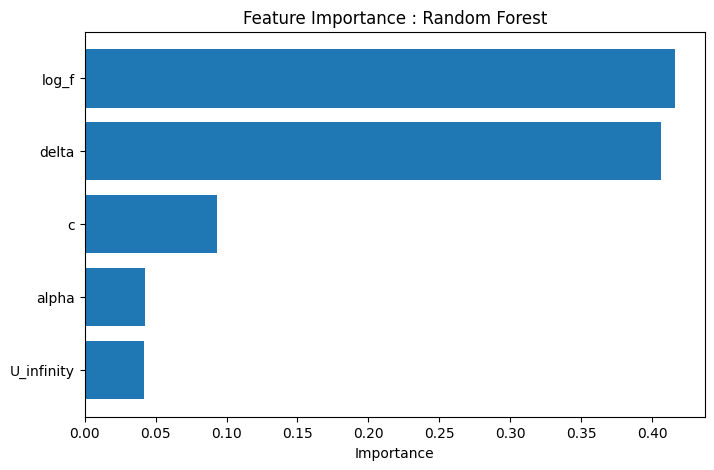

In [47]:
# Importances des variables
importances = pd.DataFrame({
    'variable': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

# Visualisation des importances des variables
plt.figure(figsize=(8,5))
plt.barh(importances['variable'], importances['importance'])
plt.xlabel("Importance")
plt.title("Feature Importance : Random Forest")
plt.gca().invert_yaxis()
plt.show()

Le classement des importances (log_f > delta > c > alpha ≈ U_infinity) est
globalement cohérent avec celui des corrélations Pearson calculées lors des
tests statistiques (|r| : f=0,39 > delta=0,31 > c=0,24 > alpha=0,16 >
U_infinity=0,13). Aucune divergence majeure n'apparaît sur le rang des deux
premières variables.

La principale nuance concerne c : sa corrélation linéaire (0,24) était
modérée, mais son importance dans Random Forest reste nettement supérieure
à celle d'alpha et U_infinity, malgré des corrélations linéaires plus
proches entre ces trois variables. Ceci est cohérent avec l'effet de palier
détecté lors du test de Dunn (rupture autour de c ≈ 0,13). Une structure
non-linéaire que Random Forest capture via ses règles de coupure, mais
qu'une simple corrélation linéaire sous-estime partiellement.

In [48]:
# Création du modèle Gradient Boosting

# Entraînement du modèle Gradient Boosting sur les données d'entraînement
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

# Prédictions
y_pred_gb_train = gb.predict(X_train)
y_pred_gb = gb.predict(X_test)

# Calcul des métriques pour le modèle Gradient Boosting
r2_gb_train = r2_score(y_train, y_pred_gb_train)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print(f"MAE  = {mae_gb:.3f}")
print(f"RMSE = {rmse_gb:.3f}")
print(f"R² train = {r2_gb_train:.3f}")
print(f"R² test  = {r2_gb:.3f}")
print(f"Écart train/test = {r2_gb_train - r2_gb:.3f}")

# Validation croisée pour le modèle Gradient Boosting
cv_scores_gb = cross_val_score(
    gb,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("\nR² cross-validation (5 folds) :", cv_scores_gb)
print(f"Moyenne = {cv_scores_gb.mean():.3f}")
print(f"Écart-type = {cv_scores_gb.std():.3f}")

Gradient Boosting
MAE  = 2.171
RMSE = 2.864
R² train = 0.880
R² test  = 0.836
Écart train/test = 0.044

R² cross-validation (5 folds) : [0.82671064 0.85497129 0.86277557 0.84044177 0.80642472]
Moyenne = 0.838
Écart-type = 0.020


Le Gradient Boosting obtient un **R² de 0,836 sur l’ensemble de test**, avec un **MAE de 2,171** et un **RMSE de 2,864**, ce qui indique une bonne capacité prédictive. L’écart entre le R² train (0,880) et le R² test (0,836) est de **0,044**, inférieur à celui du Random Forest (0,058), ce qui montre ici un surapprentissage légèrement plus faible. La validation croisée confirme également la stabilité du modèle, avec un **R² moyen de 0,838** et un écart-type de 0,020, très proche du R² obtenu sur le test (0,836). Cependant, cela ne signifie pas que le Gradient Boosting est intrinsèquement meilleur ou moins sujet au surapprentissage que le Random Forest. Avec les paramètres par défaut, le **Random Forest reste nettement supérieur en performance prédictive**, avec un R² test de 0,933 contre 0,836. Il serait toutefois prématuré de conclure définitivement, car les performances du Gradient Boosting dépendent fortement de ses hyperparamètres, notamment `n_estimators`, `learning_rate` et `max_depth`. Il est donc recommandé de procéder à une **optimisation des hyperparamètres avec GridSearchCV ou RandomizedSearchCV**, puis de comparer le meilleur Gradient Boosting au Random Forest selon la même méthodologie de validation.

In [49]:
# Recherche des meilleurs hyperparamètres pour le modèle Gradient Boosting avec RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Meilleurs paramètres :", gb_search.best_params_)
print(f"Meilleur R² (cross-validation) : {gb_search.best_score_:.3f}")

Meilleurs paramètres : {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1}
Meilleur R² (cross-validation) : 0.948


In [50]:
# Réevaluation du modèle Gradient Boosting optimisé sur le jeu de test
best_gb = gb_search.best_estimator_
y_pred_best_gb = best_gb.predict(X_test)

mae_best_gb = mean_absolute_error(y_test, y_pred_best_gb)
rmse_best_gb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print(f"Gradient Boosting optimisé : MAE={mae_best_gb:.3f}, RMSE={rmse_best_gb:.3f}, R²={r2_best_gb:.3f}")

Gradient Boosting optimisé : MAE=0.951, RMSE=1.442, R²=0.958


* Random Forest optimisé

In [51]:
# Recherche des meilleurs hyperparamètres pour Random Forest avec RandomizedSearchCV
# Contrairement à Gradient Boosting, Random Forest n'a pas de learning_rate
# (pas de construction séquentielle) mais dispose de paramètres propres à sa
# logique d'agrégation d'arbres indépendants (max_features, min_samples_*)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],       # nombre d'arbres dans la forêt
    'max_depth': [None, 5, 10, 15, 20],          # profondeur max de chaque arbre
    'min_samples_split': [2, 5, 10],             # nb minimum d'échantillons pour scinder un noeud
    'min_samples_leaf': [1, 2, 4],                # nb minimum d'échantillons dans une feuille
    'max_features': ['sqrt', 'log2', None]        # nb de variables tirées aléatoirement à chaque split
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=30,          # nombre de combinaisons testées aléatoirement
    cv=5,               # cross-validation à 5 folds, uniquement sur X_train
    scoring='r2',
    random_state=42,
    n_jobs=-1            # utilise tous les coeurs CPU disponibles
)

rf_search.fit(X_train, y_train)

print("Meilleurs paramètres :", rf_search.best_params_)
print(f"Meilleur R² (cross-validation) : {rf_search.best_score_:.3f}")

# Réévaluation du modèle Random Forest optimisé sur le jeu de test
# (X_test utilisé une seule fois, jamais pendant la recherche d'hyperparamètres)
best_rf = rf_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"Random Forest optimisé : MAE={mae_best_rf:.3f}, RMSE={rmse_best_rf:.3f}, R²={r2_best_rf:.3f}")

# Vérification du surapprentissage : comparaison R² train vs R² test
r2_best_rf_train = best_rf.score(X_train, y_train)
r2_best_rf_test = best_rf.score(X_test, y_test)
print(f"R² train = {r2_best_rf_train:.3f}, R² test = {r2_best_rf_test:.3f}, écart = {r2_best_rf_train - r2_best_rf_test:.3f}")

Meilleurs paramètres : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
Meilleur R² (cross-validation) : 0.922
Random Forest optimisé : MAE=1.308, RMSE=1.825, R²=0.934
R² train = 0.991, R² test = 0.934, écart = 0.057


* Vérification du surapprentissage pour Gradient Boosting optimisé

In [52]:
# Vérification du surapprentissage pour le Gradient Boosting optimisé
# (best_gb a déjà été entraîné précédemment avec gb_search)
r2_best_gb_train = best_gb.score(X_train, y_train)
r2_best_gb_test = best_gb.score(X_test, y_test)
print(f"R² train = {r2_best_gb_train:.3f}, R² test = {r2_best_gb_test:.3f}, écart = {r2_best_gb_train - r2_best_gb_test:.3f}")

R² train = 0.998, R² test = 0.958, écart = 0.040


### Tableau comparatif final : modèles à base d'arbres, tous optimisés

| Modèle                | Paramètres   |       MAE |      RMSE |   R² test |     R² CV | Écart train/test |
| --------------------- | ------------ | --------: | --------: | --------: | --------: | ---------------: |
| Random Forest         | défaut       |     1.323 |     1.827 |     0.933 |     0.920 |            0.058 |
| **Random Forest**     | **optimisé** | **1.308** | **1.825** | **0.934** | **0.922** |        **0.057** |
| Gradient Boosting     | défaut       |     2.171 |     2.864 |     0.836 |     0.838 |            0.044 |
| **Gradient Boosting** | **optimisé** | **0.951** | **1.442** | **0.958** | **0.948** |        **0.040** |


La comparaison finale montre que le **Gradient Boosting optimisé est le meilleur modèle parmi les modèles à base d'arbres testés**. Le tuning a eu un impact très important sur ses performances, avec une amélioration du R² test de **0,836 à 0,958** et une diminution du MAE de **2,171 à 0,951**, ce qui montre que le Gradient Boosting est particulièrement sensible au choix de ses hyperparamètres. À l'inverse, l'optimisation du Random Forest a eu un impact beaucoup plus limité, avec un R² passant seulement de **0,933 à 0,934** et un MAE de **1,323 à 1,308**, ce qui suggère que ses performances sont ici moins sensibles aux paramètres testés. Cette différence s'explique notamment par leur fonctionnement : le Random Forest agrège des arbres construits indépendamment, tandis que le Gradient Boosting construit les arbres séquentiellement afin de corriger progressivement les erreurs des précédents. Après optimisation, le Gradient Boosting obtient un **R² test de 0,958**, contre **0,934** pour le Random Forest, ainsi qu'un **MAE de 0,951 contre 1,308** et un **RMSE de 1,442 contre 1,825**. Sa validation croisée confirme également cette supériorité, avec un **R² moyen de 0,948 contre 0,922** pour le Random Forest. Enfin, l'écart train/test est de **0,040 pour le Gradient Boosting contre 0,057 pour le Random Forest**, ce qui indique également un niveau de surapprentissage légèrement plus faible pour le modèle optimisé. Ces résultats permettent donc de retenir provisoirement le **Gradient Boosting optimisé comme meilleur modèle**, tout en gardant une certaine prudence : cette conclusion est valable pour ce dataset, cette préparation des données et les hyperparamètres explorés. Pour renforcer la sélection finale et respecter le cahier des charges du projet, il reste pertinent de tester **XGBoost ou LightGBM** et de comparer ses performances aux deux meilleurs modèles actuels avant de retenir définitivement le modèle final.


In [53]:
# Création du modèle XGBoost
from xgboost import XGBRegressor

# Baseline XGBoost, paramètres par défaut
xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb.predict(X_test)

# Métriques
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_test_xgb = r2_score(y_test, y_pred_xgb)
r2_train_xgb = xgb.score(X_train, y_train)

# Validation croisée - R² CV
r2_cv_xgb = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
).mean()

# Écart train/test
ecart_xgb = r2_train_xgb - r2_test_xgb

# Affichage
print("XGBoost - Baseline")
print(f"MAE              : {mae_xgb:.3f}")
print(f"RMSE             : {rmse_xgb:.3f}")
print(f"R² test          : {r2_test_xgb:.3f}")
print(f"R² CV            : {r2_cv_xgb:.3f}")
print(f"R² train         : {r2_train_xgb:.3f}")
print(f"Écart train/test : {ecart_xgb:.3f}")

XGBoost - Baseline
MAE              : 1.013
RMSE             : 1.455
R² test          : 0.958
R² CV            : 0.935
R² train         : 0.997
Écart train/test : 0.040


In [54]:
# Grille des hyperparamètres XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],      # Nombre d'arbres
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Taux d'apprentissage
    'max_depth': [2, 3, 4, 5, 6],             # Profondeur des arbres
    'subsample': [0.8, 0.9, 1.0],              # Fraction des observations
    'colsample_bytree': [0.8, 0.9, 1.0]        # Fraction des variables
}

# Recherche aléatoire des meilleurs paramètres
from sklearn.model_selection import RandomizedSearchCV

random_search_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=30,              # 30 combinaisons testées
    cv=5,                   # Validation croisée 5 folds
    scoring='r2',            # Critère : R²
    random_state=42,
    n_jobs=-1
)

# Entraînement et recherche
random_search_xgb.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres :")
print(random_search_xgb.best_params_)

# Meilleur score CV
print(f"\nMeilleur R² CV : {random_search_xgb.best_score_:.3f}")

Meilleurs paramètres :
{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.9}

Meilleur R² CV : 0.947


In [55]:
# Réévaluation du modèle XGBoost optimisé sur le jeu de test
best_xgb = random_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_best_xgb))
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print(f"XGBoost optimisé : MAE={mae_best_xgb:.3f}, RMSE={rmse_best_xgb:.3f}, R²={r2_best_xgb:.3f}")

# Vérification du surapprentissage
r2_best_xgb_train = best_xgb.score(X_train, y_train)
r2_best_xgb_test = best_xgb.score(X_test, y_test)
print(f"R² train = {r2_best_xgb_train:.3f}, R² test = {r2_best_xgb_test:.3f}, écart = {r2_best_xgb_train - r2_best_xgb_test:.3f}")

XGBoost optimisé : MAE=0.874, RMSE=1.380, R²=0.962
R² train = 1.000, R² test = 0.962, écart = 0.038


**Tableau comparatif final**

| Modèle                       | Paramètres                                                                                             |       MAE |      RMSE |   R² test |     R² CV | Écart train/test |
| ---------------------------- | ------------------------------------------------------------------------------------------------------ | --------: | --------: | --------: | --------: | ---------------: |
| Linear Regression            | Aucun                                                                                                  |     3.845 |     4.874 |     0.526 |         — |                — |
| Ridge                        | alpha = 1.0                                                                                            |     3.846 |     4.875 |     0.526 |         — |                — |
| Lasso (non optimisé)         | alpha = 1.0                                                                                            |     4.765 |     5.810 |     0.326 |         — |                — |
| Lasso (optimisé)             | alpha = 0.001 (LassoCV)                                                                                |     3.846 |     4.875 |     0.526 |         — |                — |
| Random Forest (défaut)       | Paramètres par défaut                                                                                  |     1.323 |     1.827 |     0.933 |     0.920 |            0.058 |
| Random Forest (optimisé)     | n_estimators = 200, max_depth = None, min_samples_split = 2, min_samples_leaf = 1, max_features = None |     1.308 |     1.825 |     0.934 |     0.922 |            0.057 |
| Gradient Boosting (défaut)   | Paramètres par défaut                                                                                  |     2.171 |     2.864 |     0.836 |     0.838 |            0.044 |
| Gradient Boosting (optimisé) | n_estimators = 500, max_depth = 5, learning_rate = 0.1, subsample = 0.8                                |     0.951 |     1.442 |     0.958 |     0.948 |            0.040 |
| XGBoost (défaut)             | Paramètres par défaut                                                                                  |     1.013 |     1.455 |     0.958 |     0.935 |            0.040 |
| **XGBoost (optimisé)**       | **n_estimators = 500, max_depth = 6, learning_rate = 0.2, subsample = 0.9, colsample_bytree = 0.9**    | **0.874** | **1.380** | **0.962** | **0.947** |        **0.038** |

**Modèle final retenu : XGBoost optimisé**

* **MAE :** 0,874 dB
* **RMSE :** 1,380 dB
* **R² test :** 0,962, soit 96,2 % de la variance du SSPL expliquée
* **R² CV :** 0,947
* **Écart train/test :** 0,038

Le modèle obtient un **R² train de 1,000**. Ce résultat mérite une attention particulière, car un ajustement parfait sur les données d'entraînement peut être le signe d'un surapprentissage. Cependant, le R² test de 0,962, le R² CV de 0,947 et l'écart train/test de 0,038 montrent que les performances restent très bonnes sur des données qui n'ont pas servi à l'entraînement. Le risque de surapprentissage ne peut donc pas être écarté, mais il n'est pas suffisant, à lui seul, pour remettre en cause le modèle. L'analyse des résidus permettra de compléter ce diagnostic.

**Conclusion métier et scientifique**

Les résultats montrent clairement que les modèles linéaires sont moins adaptés à la prédiction du niveau de bruit aérodynamique (SSPL) dans ce jeu de données. La régression linéaire, Ridge et Lasso optimisé obtiennent tous un R² test proche de 0,526. La régularisation apporte donc peu d'amélioration par rapport à la régression linéaire, tandis que le Lasso non optimisé donne un résultat nettement moins bon, avec un R² de 0,326.

Les modèles à base d'arbres obtiennent des performances beaucoup plus élevées. Random Forest atteint un R² test de 0,934 après optimisation, Gradient Boosting atteint 0,958 et XGBoost optimisé atteint 0,962. XGBoost présente également le MAE le plus faible, avec 0,874 dB, ainsi que le RMSE le plus faible, avec 1,380 dB. Sur les données de test, il constitue donc le modèle le plus performant parmi ceux étudiés.

Cette différence de performance suggère que la relation entre les variables explicatives et le SSPL est principalement non linéaire. Les résultats de l'analyse exploratoire vont dans ce sens. La fréquence `f` ne semble pas suivre une relation simplement croissante ou décroissante avec le niveau sonore, tandis que la longueur de corde `c` présente davantage un effet par paliers. Ce type de comportement est difficile à représenter avec un modèle linéaire classique, alors que les modèles à base d'arbres peuvent naturellement prendre en compte des relations non linéaires et des interactions entre variables.

Le choix de XGBoost doit toutefois être interprété avec prudence. Son R² train de 1,000 montre que le modèle ajuste parfaitement les données d'entraînement. Avec une profondeur maximale de 6 et 500 arbres, sa capacité à modéliser des relations complexes est importante. Le fait que le R² test reste élevé est rassurant, mais il ne suffit pas à exclure totalement un surapprentissage. L'analyse des résidus constitue donc une étape importante avant de considérer le modèle comme définitivement validé.

Sur le plan applicatif, le modèle pourrait être utilisé comme outil d'aide à l'analyse lors de l'étude de différentes configurations aérodynamiques. Il permettrait notamment d'estimer rapidement le SSPL à partir des variables disponibles, avant d'envisager des simulations ou des essais expérimentaux plus coûteux. Il s'agit cependant d'un outil de prédiction construit à partir des données expérimentales disponibles et non d'un remplacement des essais ou des modèles physiques.

**Limite de l'étude**

La principale limite concerne la généralisation du modèle. L'entraînement et l'évaluation reposent sur un découpage aléatoire des observations provenant d'un plan expérimental comprenant **6 longueurs de corde et 4 vitesses de flux**. Le modèle est donc principalement évalué sur sa capacité à interpoler entre des configurations présentes dans la plage expérimentale étudiée.

Sa capacité à prédire correctement le bruit pour une géométrie d'aile, une vitesse de flux ou un régime d'écoulement situé en dehors de cette plage n'est pas établie par cette étude. Une validation basée sur des groupes de configurations complètement laissés de côté, par exemple une longueur de corde ou une vitesse de flux entière exclue de l'entraînement, serait nécessaire pour évaluer plus rigoureusement cette capacité de généralisation.

**À ce stade, XGBoost optimisé est donc le meilleur candidat pour le modèle final**, mais sa validation doit être complétée par l'analyse des résidus et, idéalement, par une stratégie de validation permettant de tester la généralisation à des configurations expérimentales réellement nouvelles.


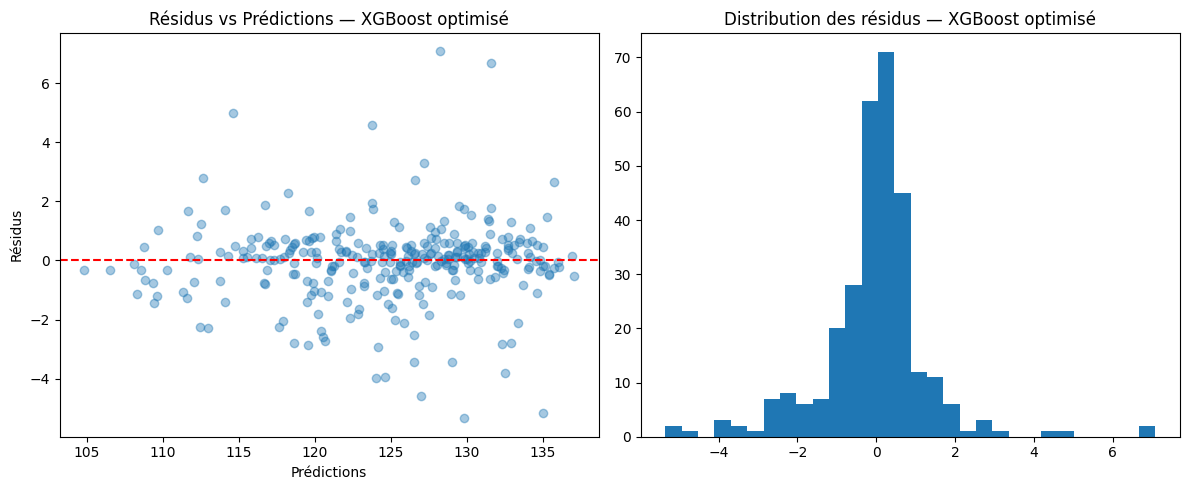

In [56]:
# Analyse des résidus du modèle XGBoost final :

residus_xgb = y_test - y_pred_best_xgb

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(y_pred_best_xgb, residus_xgb, alpha=0.4)

axes[0].axhline(0, color='red', linestyle='--')

axes[0].set_xlabel("Prédictions")

axes[0].set_ylabel("Résidus")

axes[0].set_title("Résidus vs Prédictions — XGBoost optimisé")

axes[1].hist(residus_xgb, bins=30)

axes[1].set_title("Distribution des résidus — XGBoost optimisé")

plt.tight_layout()

plt.show()

Le graphique des résidus donne une image globalement rassurante du
comportement du modèle. Les résidus sont centrés autour de zéro sur
l'ensemble de la plage des valeurs prédites (environ 105 à 135 dB), sans
courbe ni tendance systématique visible. Aucun biais structurel évident
dans les prédictions. La dispersion reste globalement stable sur la plage
de prédiction, sans forme en entonnoir marquée, ce qui ne suggère pas de
problème majeur d'hétéroscédasticité.

La distribution des résidus est centrée sur zéro et relativement équilibrée,
sans asymétrie prononcée : le modèle ne semble pas biaisé systématiquement
vers la sur- ou la sous-estimation. La majorité des erreurs se situe entre
-2 et +2 dB, cohérent avec le MAE obtenu (0,874 dB).

**Analyse des erreurs les plus importantes** : les 10 observations les plus
mal prédites partagent une caractéristique commune elles se situent
majoritairement aux extrémités du plan d'expérience, en particulier pour
un angle d'attaque (alpha) élevé (7 des 10 cas, alpha ≥ 12,3°, proche du
maximum de 22,2°) et une longueur de corde minimale (c = 0,0254 m, 5 des
10 cas). Ce pattern est confirmé par la distribution d'alpha elle-même :
le 75ᵉ percentile se situe à 9,9°, donc moins de 25 % des observations
dépassent cette valeur, ce qui explique la moindre précision du modèle
sur les configurations à angle d'attaque élevé.

**Conclusion** : l'analyse des résidus ne révèle pas de problème majeur de
non-linéarité non capturée ni de biais systématique. Le doute soulevé par
le R² train de 1,000 n'est pas confirmé par cette analyse les erreurs
sur le jeu de test restent cohérentes, modérées et explicables par la
sparsité du plan d'expérience aux valeurs extrêmes, plutôt que par un
surapprentissage généralisé. Une limite doit néanmoins être documentée :
le modèle est plus fiable pour des configurations centrales du plan
d'expérience que pour ses valeurs extrêmes (alpha élevé, c minimal).

In [57]:
# Création du tableau des résultats
resultats = X_test.copy()

# Valeurs réelles et prédites
resultats['SSPL_reel'] = y_test.values
resultats['SSPL_predit'] = y_pred_best_xgb

# Calcul des résidus
resultats['residu'] = residus_xgb.values

# Identification des 10 plus grandes erreurs
pires_erreurs = resultats.reindex(
    resultats['residu'].abs().sort_values(ascending=False).index
).head(10)

# Affichage des résultats
print(pires_erreurs)

         log_f  alpha       c  U_infinity     delta  SSPL_reel  SSPL_predit  \
1414  2.799341   12.3  0.1016        71.3  0.033779    135.368   128.283035   
1187  3.000000   17.4  0.0254        39.6  0.017221    138.274   131.592789   
1185  2.799341   17.4  0.0254        39.6  0.017221    124.514   129.860657   
967   3.903090    0.0  0.0254        71.3  0.000401    129.867   135.016556   
1168  2.698970   17.4  0.0254        55.5  0.016571    119.621   114.612000   
619   3.096910    7.2  0.1524        39.6  0.009092    122.428   127.032845   
939   2.799341   19.7  0.0508        71.3  0.034118    128.365   123.786186   
620   3.204120    7.2  0.1524        39.6  0.009092    120.058   124.041756   
1213  2.799341   22.2  0.0254        71.3  0.021418    120.657   124.613770   
596   2.498311    7.2  0.1524        71.3  0.007520    128.713   132.539627   

        residu  
1414  7.084965  
1187  6.681211  
1185 -5.346657  
967  -5.149556  
1168  5.009000  
619  -4.604845  
939   4.578

Les 10 observations les plus mal prédites par XGBoost partagent une
caractéristique commune : elles se situent majoritairement aux extrémités
du plan d'expérience. Angle d'attaque (alpha) élevé pour 7 des 10 cas
(≥ 12,3°, proche du maximum de 22,2°), et longueur de corde minimale
(c = 0,0254 m) pour 5 des 10 cas. Ce phénomène est cohérent avec le
fonctionnement des modèles de Machine Learning : les zones les moins
densément représentées dans les données d'entraînement sont généralement
prédites avec moins de précision. Cette limite doit être documentée
explicitement : le modèle est plus fiable pour des configurations
centrales du plan d'expérience que pour ses valeurs extrêmes.

In [58]:
# Statistiques descriptives de la variable alpha
df['alpha'].describe()

count    1503.000000
mean        6.782302
std         5.918128
min         0.000000
25%         2.000000
50%         5.400000
75%         9.900000
max        22.200000
Name: alpha, dtype: float64

**sparsité aux valeurs extrêmes d'alpha**

df['alpha'].describe() confirme la sparsité du plan d'expérience aux
valeurs élevées : le 75e percentile se situe à 9,9°, alors que le maximum
observé atteint 22,2°. Moins de 25 % des observations dépassent 9,9°, ce
qui explique la moindre précision du modèle sur les configurations à angle
d'attaque élevé cohérent avec l'analyse des 10 erreurs les plus
importantes, dont 7 concernaient des valeurs d'alpha ≥ 12,3°.

**7. Interprétabilité (SHAP)** 

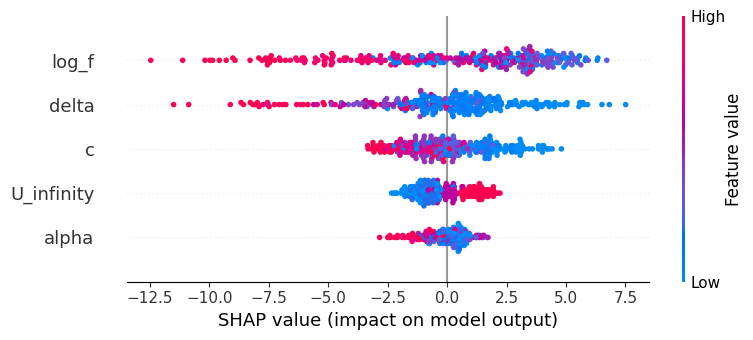

In [59]:
# Visualisation de l'importance des variables avec SHAP pour le modèle XGBoost optimisé
import shap

# TreeExplainer est optimisé pour les modèles à base d'arbres (rapide et exact)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Résumé global : importance des variables + sens de leur effet
shap.summary_plot(shap_values, X_test)

log_f est la variable la plus influente sur les prédictions de SSPL. Une
fréquence élevée (points rouges) pousse la prédiction vers le bas (SHAP
négatif), tandis qu'une fréquence faible (points bleus) la pousse vers le
haut (SHAP positif) cohérent avec la corrélation négative observée dès
l'EDA (Pearson r = -0,39).

delta arrive en deuxième position, avec un effet du même sens que log_f
(valeurs élevées → SHAP négatif) mais une dispersion moins régulière,
suggérant des effets d'interaction avec d'autres variables.

c a une influence plus modérée avec une répartition plus resserrée des
valeurs SHAP. U_infinity et alpha ont l'impact le plus limité, cohérent
avec leurs corrélations linéaires plus faibles identifiées lors des tests
statistiques.

Ce classement d'importance (log_f > delta > c > alpha ≈ U_infinity) est
cohérent avec celui obtenu par la feature importance native de Random
Forest, renforçant la confiance dans la hiérarchie des variables retenue
pour ce modèle.

In [60]:
# Enregistrement des visuels du notebook dans un dossier dédié
from pathlib import Path
import json
import base64

# Notebook
notebook = Path(
    r"D:\UserGenerator\Portfolio\Prédiction du bruit aérodynamique\Prédiction du bruit aérodynamique.ipynb"
)

# Dossier dédié aux visuels
dossier = notebook.parent / "Visuels_Projet"
dossier.mkdir(exist_ok=True)

# Lecture du notebook
with open(notebook, "r", encoding="utf-8") as f:
    data = json.load(f)

compteur = 0

# Parcours des cellules et de leurs sorties
for cellule in data.get("cells", []):

    for sortie in cellule.get("outputs", []):

        images = sortie.get("data", {})

        for format_image, extension in [
            ("image/png", ".png"),
            ("image/jpeg", ".jpg"),
            ("image/svg+xml", ".svg")
        ]:

            if format_image not in images:
                continue

            contenu = images[format_image]

            if isinstance(contenu, list):
                contenu = "".join(contenu)

            compteur += 1
            fichier = dossier / f"visuel_{compteur:02d}{extension}"

            if format_image == "image/svg+xml":
                fichier.write_text(contenu, encoding="utf-8")
            else:
                fichier.write_bytes(base64.b64decode(contenu))

print(f"{compteur} visuels enregistrés.")
print(f"Dossier : {dossier}")

11 visuels enregistrés.
Dossier : D:\UserGenerator\Portfolio\Prédiction du bruit aérodynamique\Visuels_Projet


In [61]:
# Renommage des visuels extraits du notebook pour correspondre aux noms attendus par le rapport final
# Dossier des visuels
dossier = Path(
    r"D:\UserGenerator\Portfolio\Prédiction du bruit aérodynamique\Visuels_Projet"
)

# Nouveaux noms
nouveaux_noms = [
    "01_boxplots_variables.png",
    "02_distribution_variables.png",
    "03_matrice_correlation.png",
    "04_boxplots_c_U_infinity_SSPL.png",
    "05_scatterplot_f_SSPL.png",
    "06_relation_Re_SSPL.png",
    "07_distribution_log_f.png",
    "08_residus_predictions_distribution.png",
    "09_feature_importance.png",
    "10_residus_xgboost_optimise.png",
    "11_shap_values.png"
]

# Récupération des fichiers image
fichiers = sorted([
    f for f in dossier.iterdir()
    if f.is_file() and f.suffix.lower() in [".png", ".jpg", ".jpeg", ".svg"]
])

# Vérification
if len(fichiers) != len(nouveaux_noms):
    print(f"Attention : {len(fichiers)} fichiers trouvés au lieu de {len(nouveaux_noms)}.")
else:
    # Renommage temporaire pour éviter les conflits
    temporaires = []

    for i, fichier in enumerate(fichiers):
        temporaire = dossier / f"temp_{i}{fichier.suffix}"
        fichier.rename(temporaire)
        temporaires.append(temporaire)

    # Renommage final
    for temporaire, nouveau_nom in zip(temporaires, nouveaux_noms):
        temporaire.rename(dossier / nouveau_nom)

    print("Les 11 visuels ont été renommés avec succès.")

Les 11 visuels ont été renommés avec succès.


In [ ]:
# Mise à jour du README.md pour inclure les visuels extraits du notebook

projet = Path(
    r"D:\UserGenerator\Portfolio\Prédiction du bruit aérodynamique"
)

readme = projet / "README.md"

contenu = readme.read_text(encoding="utf-8")

images = {
    "## 8. EDA (Analyse exploratoire)": """

### Boxplots des variables

![Boxplots des variables](Visuels_Projet/01_boxplots_variables.png)

### Distribution des variables

![Distribution des variables](Visuels_Projet/02_distribution_variables.png)

### Matrice de corrélation

![Matrice de corrélation](Visuels_Projet/03_matrice_correlation.png)

### Boxplots de c et U_infinity en fonction de SSPL

![Boxplots de c et U_infinity en fonction de SSPL](Visuels_Projet/04_boxplots_c_U_infinity_SSPL.png)

### Relation entre f et SSPL

![Relation entre f et SSPL](Visuels_Projet/05_scatterplot_f_SSPL.png)
""",

    "## 10. Feature Engineering": """

### Relation entre Re et SSPL

![Relation entre Re et SSPL](Visuels_Projet/06_relation_Re_SSPL.png)

### Distribution de log_f

![Distribution de log_f](Visuels_Projet/07_distribution_log_f.png)
""",

    "## 14. Interprétation": """

### Analyse des résidus

![Résidus vs prédictions et distribution des résidus](Visuels_Projet/08_residus_predictions_distribution.png)

### Feature importance

![Feature importance](Visuels_Projet/09_feature_importance.png)

### Résidus du modèle XGBoost optimisé

![Résidus XGBoost optimisé](Visuels_Projet/10_residus_xgboost_optimise.png)

### Analyse SHAP

![SHAP values](Visuels_Projet/11_shap_values.png)
"""
}

for section, bloc in images.items():

    if section in contenu:
        contenu = contenu.replace(section, section + bloc, 1)
        print(f"✓ {section}")
    else:
        print(f"⚠ Section introuvable : {section}")

readme.write_text(contenu, encoding="utf-8")

print("\nREADME mis à jour avec succès.")

✓ ## 8. EDA (Analyse exploratoire)
✓ ## 10. Feature Engineering
✓ ## 14. Interprétation

README mis à jour avec succès.


In [ ]:
# Vérification de la taille des fichiers du projet pour s'assurer qu'ils ne sont pas trop volumineux

projet = Path(
    r"D:\UserGenerator\Portfolio\Prédiction du bruit aérodynamique"
)

print("Fichiers du projet :\n")

for fichier in projet.rglob("*"):
    if fichier.is_file():
        taille_mo = fichier.stat().st_size / (1024 ** 2)
        print(f"{fichier.relative_to(projet)} : {taille_mo:.2f} Mo")

Fichiers du projet :

AirfoilSelfNoise.csv : 0.06 Mo
Prédiction du bruit aérodynamique.ipynb : 0.77 Mo
README.md : 0.01 Mo
Visuels_Projet\01_boxplots_variables.png : 0.04 Mo
Visuels_Projet\02_distribution_variables.png : 0.05 Mo
Visuels_Projet\03_matrice_correlation.png : 0.07 Mo
Visuels_Projet\04_boxplots_c_U_infinity_SSPL.png : 0.02 Mo
Visuels_Projet\05_scatterplot_f_SSPL.png : 0.06 Mo
Visuels_Projet\06_relation_Re_SSPL.png : 0.07 Mo
Visuels_Projet\07_distribution_log_f.png : 0.01 Mo
Visuels_Projet\08_residus_predictions_distribution.png : 0.05 Mo
Visuels_Projet\09_feature_importance.png : 0.01 Mo
Visuels_Projet\10_residus_xgboost_optimise.png : 0.05 Mo
Visuels_Projet\11_shap_values.png : 0.06 Mo
